# Clasificación supervisada
## Incorporando features topológicas: GSP y TSP vs STFT, CWT, SST, WPD

Este notebook extiende el notebook 06, agregando las dos técnicas
topológicas (**GSP** y **TSP**) a la comparación de clasificadores ya
realizada para las cuatro técnicas tiempo-frecuencia. Mantiene exactamente
la misma metodología — mismo split temporal, mismos clasificadores, mismo
escalado — para que los resultados sean directamente comparables a los del
notebook 06.

---

## Contexto: lo que sabemos antes de clasificar

Los notebooks 04b y 05b establecieron que, en las métricas de
discriminabilidad estadística (Cohen's $d$, Mann-Whitney, FDR y Mutual
Information), **GSP y TSP superaron a las cuatro técnicas tiempo-frecuencia**.
Este notebook responde la pregunta que esas métricas no pueden responder
por sí solas: ¿esa ventaja estadística se traduce en mejor rendimiento de
clasificación real?

Es importante notar que una mayor discriminabilidad estadística no
garantiza automáticamente mejor accuracy — depende de cómo cada
clasificador explota esa señal, y la comparación con las técnicas TF en
notebook 06 (donde el ranking de discriminabilidad no predijo exactamente
el ranking de accuracy) es la referencia para contrastar.

---

## Decisión de diseño: cómo incorporar GSP/TSP a las configuraciones

A diferencia de las técnicas TF (56 features por 14 canales, divididas en
Config A "todos los canales" y Config B "solo canales alfa"), GSP y TSP
entregan **4 features agregadas globalmente**, sin dimensión de canal. Por
lo tanto:

- **STFT, CWT, SST, WPD** se evalúan igual que en el notebook 06: Config A
  (56 features) y Config B (16 features, canales alfa).
- **GSP y TSP** se evalúan en una **Config Única** (sus 4 features), sin
  desglose A/B — no hay canales que restringir.

### Total de combinaciones

(4 técnicas TF × 2 configuraciones + 2 técnicas topológicas × 1 configuración)
× 3 clasificadores = (8 + 2) × 3 = **30 combinaciones**.

### Clasificadores y split — sin cambios respecto al notebook 06

| Clasificador | Justificación |
|---|---|
| Regresión Logística | Baseline lineal |
| SVM (kernel RBF) | Robusto con muestras pequeñas y alta dimensión |
| Random Forest | Maneja multicolinealidad; entrega importancia de features |

Split temporal por bloques (block_size=30, bloques pares → train, impares
→ test) — idéntico al notebook 06, para que los resultados de STFT, CWT,
SST y WPD en este notebook coincidan exactamente con los del notebook 06
y la comparación con GSP/TSP sea válida.

---

## Estructura del notebook

**Sección 1:** preparación de datos — carga de las 6 técnicas, split temporal y escalado.

**Sección 2:** entrenamiento y evaluación — 30 combinaciones. Tabla comparativa.

**Sección 3:** importancia de features — Random Forest, con tratamiento separado para técnicas con/sin estructura de canal.

**Sección 4:** síntesis (sin conclusiones — pendiente de ejecución con datos reales).

# Sección 1: Preparación de Datos

Split temporal sin data leakage, selección de configuraciones de features, y escalado.

In [1]:
## Sección 1: Preparación de Datos
## Cargar datasets tabulares

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores fija -- 4 técnicas TF + 2 técnicas topológicas
COLORS = {
    'STFT': '#2980b9',
    'CWT':  '#c0392b',
    'SST':  '#27ae60',
    'WPD':  '#e67e22',
    'GSP':  '#8e44ad',
    'TSP':  '#16a085',
}
TECNICAS_TF   = ['STFT', 'CWT', 'SST', 'WPD']
TECNICAS_TOPO = ['GSP', 'TSP']
TECNICAS      = TECNICAS_TF + TECNICAS_TOPO

# Cargar los cuatro datasets TF
features_stft = pd.read_csv('data/features/features_stft.csv')
features_cwt  = pd.read_csv('data/features/features_cwt.csv')
features_sst  = pd.read_csv('data/features/features_sst.csv')
features_wpd  = pd.read_csv('data/features/features_wpd.csv')

# Cargar los dos datasets topológicos
features_gsp = pd.read_csv('data/features/features_gsp.csv')
features_tsp = pd.read_csv('data/features/features_tsp.csv')

datasets_raw = {
    'STFT': features_stft, 'CWT': features_cwt, 'SST': features_sst, 'WPD': features_wpd,
    'GSP': features_gsp,   'TSP': features_tsp,
}

Xs = {}
ys = {}
for name, df in datasets_raw.items():
    # GSP/TSP traen columna auxiliar 'Estado' (notebook 04b/05b) -- se descarta si existe
    cols_drop = [c for c in ['label', 'Estado'] if c in df.columns]
    Xs[name] = df.drop(columns=cols_drop).values
    ys[name] = df['label'].values

print('Shape de cada dataset:')
for name in TECNICAS:
    X, y = Xs[name], ys[name]
    print(f'  {name}: X={X.shape}, clase 0={np.sum(y==0)}, clase 1={np.sum(y==1)}')

print(f'\nNombres de features TF ({len(features_stft.columns)-1}):')
print(features_stft.columns[:-1].tolist())
print(f'\nNombres de features GSP (4):')
print([c for c in features_gsp.columns if c not in ('label', 'Estado')])
print(f'Nombres de features TSP (4):')
print([c for c in features_tsp.columns if c not in ('label', 'Estado')])


Shape de cada dataset:
  STFT: X=(231, 56), clase 0=125, clase 1=106
  CWT: X=(231, 56), clase 0=125, clase 1=106
  SST: X=(231, 56), clase 0=125, clase 1=106
  WPD: X=(231, 56), clase 0=125, clase 1=106
  GSP: X=(231, 4), clase 0=125, clase 1=106
  TSP: X=(231, 4), clase 0=125, clase 1=106

Nombres de features TF (56):
['AF3_alpha_abs', 'AF3_alpha_rel', 'AF3_entropy', 'AF3_cog', 'F7_alpha_abs', 'F7_alpha_rel', 'F7_entropy', 'F7_cog', 'F3_alpha_abs', 'F3_alpha_rel', 'F3_entropy', 'F3_cog', 'FC5_alpha_abs', 'FC5_alpha_rel', 'FC5_entropy', 'FC5_cog', 'T7_alpha_abs', 'T7_alpha_rel', 'T7_entropy', 'T7_cog', 'P7_alpha_abs', 'P7_alpha_rel', 'P7_entropy', 'P7_cog', 'O1_alpha_abs', 'O1_alpha_rel', 'O1_entropy', 'O1_cog', 'O2_alpha_abs', 'O2_alpha_rel', 'O2_entropy', 'O2_cog', 'P8_alpha_abs', 'P8_alpha_rel', 'P8_entropy', 'P8_cog', 'T8_alpha_abs', 'T8_alpha_rel', 'T8_entropy', 'T8_cog', 'FC6_alpha_abs', 'FC6_alpha_rel', 'FC6_entropy', 'FC6_cog', 'F4_alpha_abs', 'F4_alpha_rel', 'F4_entropy', 'F4

In [2]:
## Verificación crítica: alineación de etiquetas entre las 6 técnicas
## El split temporal se aplica por índice posicional -- si las ventanas no
## están alineadas entre datasets, el split sería inválido para GSP/TSP.

label_ref = ys['STFT']
alineado = True
for name in TECNICAS[1:]:
    if len(ys[name]) != len(label_ref) or not np.array_equal(ys[name], label_ref):
        print(f'  ALERTA: {name} no coincide con STFT en längth/orden de etiquetas')
        alineado = False

if alineado:
    print(f'Etiquetas alineadas entre las 6 técnicas (n={len(label_ref)}). Split por índice es válido.')
else:
    raise ValueError('Las etiquetas no están alineadas -- revisar el orden de ventanas '
                     'en los CSV antes de continuar (no se puede aplicar el mismo split por índice).')


Etiquetas alineadas entre las 6 técnicas (n=231). Split por índice es válido.


In [3]:
## Split temporal por bloques (idéntico al notebook 06 -- respeta estructura
## temporal y evita data leakage)

n_samples  = Xs['STFT'].shape[0]
block_size = 30

block_numbers = np.arange(n_samples) // block_size
train_indices = np.where(block_numbers % 2 == 0)[0]
test_indices  = np.where(block_numbers % 2 == 1)[0]

print(f'Split temporal por bloques (tamaño bloque = {block_size}):')
print(f'  Bloques pares   -> train: {len(train_indices)} muestras')
print(f'  Bloques impares -> test:  {len(test_indices)} muestras')

splits = {}
for name in TECNICAS:
    X, y = Xs[name], ys[name]
    splits[name] = {
        'X_train': X[train_indices],
        'X_test':  X[test_indices],
        'y_train': y[train_indices],
        'y_test':  y[test_indices],
    }

print('\nDistribución de clases por técnica:')
for name, s in splits.items():
    pct0_train = np.mean(s['y_train'] == 0)
    pct0_test  = np.mean(s['y_test']  == 0)
    print(f'  {name} -- train clase 0: {pct0_train:.1%} | test clase 0: {pct0_test:.1%}')


Split temporal por bloques (tamaño bloque = 30):
  Bloques pares   -> train: 120 muestras
  Bloques impares -> test:  111 muestras

Distribución de clases por técnica:
  STFT -- train clase 0: 49.2% | test clase 0: 59.5%
  CWT -- train clase 0: 49.2% | test clase 0: 59.5%
  SST -- train clase 0: 49.2% | test clase 0: 59.5%
  WPD -- train clase 0: 49.2% | test clase 0: 59.5%
  GSP -- train clase 0: 49.2% | test clase 0: 59.5%
  TSP -- train clase 0: 49.2% | test clase 0: 59.5%


In [4]:
## Definir configuraciones de features
## TF: Config A (todos los canales) y Config B (solo canales alfa)
## Topológicas (GSP/TSP): Config Única -- sus 4 features, sin desglose por canal

canales_todos = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1',
                 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
canales_alfa  = ['O1', 'O2', 'P7', 'P8']
features_por_canal = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']

feature_names_tf = features_stft.columns[:-1].tolist()

def get_feature_indices(feature_names, canales):
    indices = []
    for canal in canales:
        for feat in features_por_canal:
            col = f'{canal}_{feat}'
            if col in feature_names:
                indices.append(feature_names.index(col))
    return indices

idx_config_a = get_feature_indices(feature_names_tf, canales_todos)
idx_config_b = get_feature_indices(feature_names_tf, canales_alfa)

print(f'Config A (todos los canales): {len(idx_config_a)} features')
print(f'Config B (solo canales alfa): {len(idx_config_b)} features')

# Aplicar Config A/B a las 4 técnicas TF
for name in TECNICAS_TF:
    s = splits[name]
    s['X_train_cfg'] = {'A': s['X_train'][:, idx_config_a], 'B': s['X_train'][:, idx_config_b]}
    s['X_test_cfg']  = {'A': s['X_test'][:,  idx_config_a], 'B': s['X_test'][:,  idx_config_b]}

# Config Única para GSP/TSP -- todas sus features, sin filtrar
for name in TECNICAS_TOPO:
    s = splits[name]
    s['X_train_cfg'] = {'Unica': s['X_train']}
    s['X_test_cfg']  = {'Unica': s['X_test']}

print('\nConfiguraciones por técnica:')
for name in TECNICAS:
    print(f'  {name}: {list(splits[name]["X_train_cfg"].keys())} '
          f'-> {[s.shape[1] for s in splits[name]["X_train_cfg"].values()]} features')


Config A (todos los canales): 56 features
Config B (solo canales alfa): 16 features

Configuraciones por técnica:
  STFT: ['A', 'B'] -> [56, 16] features
  CWT: ['A', 'B'] -> [56, 16] features
  SST: ['A', 'B'] -> [56, 16] features
  WPD: ['A', 'B'] -> [56, 16] features
  GSP: ['Unica'] -> [4] features
  TSP: ['Unica'] -> [4] features


In [5]:
## Escalado con StandardScaler (ajustado solo en train, por técnica y config)

def scale_split(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test), scaler

for name in TECNICAS:
    s = splits[name]
    s['X_train_sc'] = {}
    s['X_test_sc']  = {}
    s['scaler']     = {}
    for cfg_key, X_tr in s['X_train_cfg'].items():
        X_te = s['X_test_cfg'][cfg_key]
        X_tr_sc, X_te_sc, scaler = scale_split(X_tr, X_te)
        s['X_train_sc'][cfg_key] = X_tr_sc
        s['X_test_sc'][cfg_key]  = X_te_sc
        s['scaler'][cfg_key]     = scaler

print('Escalado completado para las 6 técnicas (8 configs TF + 2 configs únicas topológicas).')
for name in TECNICAS:
    for cfg_key, X_sc in splits[name]['X_train_sc'].items():
        print(f'  {name} Config {cfg_key} -- media: {X_sc.mean():.4f}, std: {X_sc.std():.4f}')


Escalado completado para las 6 técnicas (8 configs TF + 2 configs únicas topológicas).
  STFT Config A -- media: -0.0000, std: 1.0000
  STFT Config B -- media: 0.0000, std: 1.0000
  CWT Config A -- media: -0.0000, std: 1.0000
  CWT Config B -- media: -0.0000, std: 1.0000
  SST Config A -- media: 0.0000, std: 1.0000
  SST Config B -- media: 0.0000, std: 1.0000
  WPD Config A -- media: -0.0000, std: 1.0000
  WPD Config B -- media: -0.0000, std: 1.0000
  GSP Config Unica -- media: 0.0000, std: 1.0000
  TSP Config Unica -- media: 0.0000, std: 1.0000


# Sección 2: Entrenamiento y Evaluación de Clasificadores

Se entrenan 3 clasificadores (Logistic Regression, SVM RBF, Random Forest) sobre
6 técnicas (STFT, CWT, SST, WPD, GSP, TSP). Las 4 técnicas TF se evalúan en
2 configuraciones (A y B); GSP y TSP en su Config Única.

**Total: 3 × (4×2 + 2×1) = 3 × 10 = 30 combinaciones.**

In [6]:
## Definir clasificadores -- idénticos al notebook 06

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'model':        model,
        'Accuracy':     accuracy_score(y_test, y_pred),
        'F1-Score':     f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':      roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else float('nan'),
        'CM':           confusion_matrix(y_test, y_pred),
        'y_pred':       y_pred,
        'y_pred_proba': y_pred_proba,
    }

print('Clasificadores definidos.')


Clasificadores definidos.


In [7]:
## Entrenar las 30 combinaciones

config_labels = {'A': 'A (56 features)', 'B': 'B (16 features)', 'Unica': 'Única (4 features)'}

results = []
train_configs = []

for tecnica in TECNICAS:
    s = splits[tecnica]
    for cfg_key in s['X_train_sc'].keys():
        train_configs.append((
            tecnica, s['X_train_sc'][cfg_key], s['X_test_sc'][cfg_key],
            s['y_train'], s['y_test'], config_labels[cfg_key]
        ))

print(f'Entrenando {len(train_configs) * len(classifiers)} combinaciones '
      f'({len(train_configs)} dataset-configs x {len(classifiers)} clasificadores)...\n')

for tecnica, X_tr, X_te, y_tr, y_te, config_name in train_configs:
    print(f'{tecnica} -- Config {config_name}')
    for clf_name, clf in classifiers.items():
        res = train_and_evaluate(X_tr, X_te, y_tr, y_te, clone(clf))
        results.append({
            'Técnica':      tecnica,
            'Tipo':         'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia',
            'Config':       config_name,
            'Clasificador': clf_name,
            'Accuracy':     res['Accuracy'],
            'F1-Score':     res['F1-Score'],
            'ROC-AUC':      res['ROC-AUC'],
            'CM':           res['CM'],
            'y_pred':       res['y_pred'],
            'y_pred_proba': res['y_pred_proba'],
            'model':        res['model'],
        })
        print(f'  {clf_name:22s} Acc: {res["Accuracy"]:.4f}  F1: {res["F1-Score"]:.4f}  AUC: {res["ROC-AUC"]:.4f}')
    print()

results_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ('CM', 'y_pred', 'y_pred_proba', 'model')}
                            for r in results])
print('Entrenamiento completado.')


Entrenando 30 combinaciones (10 dataset-configs x 3 clasificadores)...

STFT -- Config A (56 features)
  Logistic Regression    Acc: 0.5495  F1: 0.5492  AUC: 0.6384
  SVM (RBF)              Acc: 0.5586  F1: 0.5549  AUC: 0.5663
  Random Forest          Acc: 0.5135  F1: 0.5125  AUC: 0.5424

STFT -- Config B (16 features)
  Logistic Regression    Acc: 0.5045  F1: 0.5031  AUC: 0.5387
  SVM (RBF)              Acc: 0.6216  F1: 0.6201  AUC: 0.6091
  Random Forest          Acc: 0.5315  F1: 0.5284  AUC: 0.5559

CWT -- Config A (56 features)
  Logistic Regression    Acc: 0.5315  F1: 0.5315  AUC: 0.6064
  SVM (RBF)              Acc: 0.5766  F1: 0.5764  AUC: 0.6258
  Random Forest          Acc: 0.5135  F1: 0.5116  AUC: 0.6135

CWT -- Config B (16 features)
  Logistic Regression    Acc: 0.5586  F1: 0.5533  AUC: 0.5680
  SVM (RBF)              Acc: 0.5856  F1: 0.5847  AUC: 0.6613
  Random Forest          Acc: 0.5315  F1: 0.5297  AUC: 0.5790

SST -- Config A (56 features)
  Logistic Regression    Acc

In [8]:
## Análisis comparativo -- tabla de resultados

print('=== RESULTADOS COMPLETOS (30 combinaciones) ===\n')
print(results_df.to_string(index=False))

print('\n\n=== MEJOR COMBINACION POR METRICA ===')
for metric in ['Accuracy', 'F1-Score', 'ROC-AUC']:
    best = results_df.loc[results_df[metric].idxmax()]
    print(f'\nMejor {metric}: {best["Técnica"]} | {best["Config"]} | {best["Clasificador"]} -> {best[metric]:.4f}')

print('\n\n=== PROMEDIO POR TECNICA (todas las combinaciones) ===')
avg = results_df.groupby('Técnica')[['Accuracy', 'F1-Score', 'ROC-AUC']].mean().round(4)
avg = avg.loc[TECNICAS]
print(avg.to_string())

print('\n\n=== RANKING POR ROC-AUC PROMEDIO (las 6 técnicas) ===')
ranking = avg.sort_values('ROC-AUC', ascending=False)
for i, (tecnica, row) in enumerate(ranking.iterrows(), 1):
    tipo = 'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia'
    print(f'  {i}. {tecnica:5s} ({tipo:18s}) -- AUC: {row["ROC-AUC"]:.4f} | Acc: {row["Accuracy"]:.4f} | F1: {row["F1-Score"]:.4f}')

print('\n\n=== PROMEDIO POR TIPO DE TECNICA (TF vs Topológica) ===')
avg_tipo = results_df.groupby('Tipo')[['Accuracy', 'F1-Score', 'ROC-AUC']].mean().round(4)
print(avg_tipo.to_string())


=== RESULTADOS COMPLETOS (30 combinaciones) ===

Técnica              Tipo             Config        Clasificador  Accuracy  F1-Score  ROC-AUC
   STFT Tiempo-frecuencia    A (56 features) Logistic Regression  0.549550  0.549220 0.638384
   STFT Tiempo-frecuencia    A (56 features)           SVM (RBF)  0.558559  0.554946 0.566330
   STFT Tiempo-frecuencia    A (56 features)       Random Forest  0.513514  0.512524 0.542424
   STFT Tiempo-frecuencia    B (16 features) Logistic Regression  0.504505  0.503053 0.538721
   STFT Tiempo-frecuencia    B (16 features)           SVM (RBF)  0.621622  0.620111 0.609091
   STFT Tiempo-frecuencia    B (16 features)       Random Forest  0.531532  0.528431 0.555892
    CWT Tiempo-frecuencia    A (56 features) Logistic Regression  0.531532  0.531494 0.606397
    CWT Tiempo-frecuencia    A (56 features)           SVM (RBF)  0.576577  0.576439 0.625758
    CWT Tiempo-frecuencia    A (56 features)       Random Forest  0.513514  0.511571 0.613468
    CWT Tie

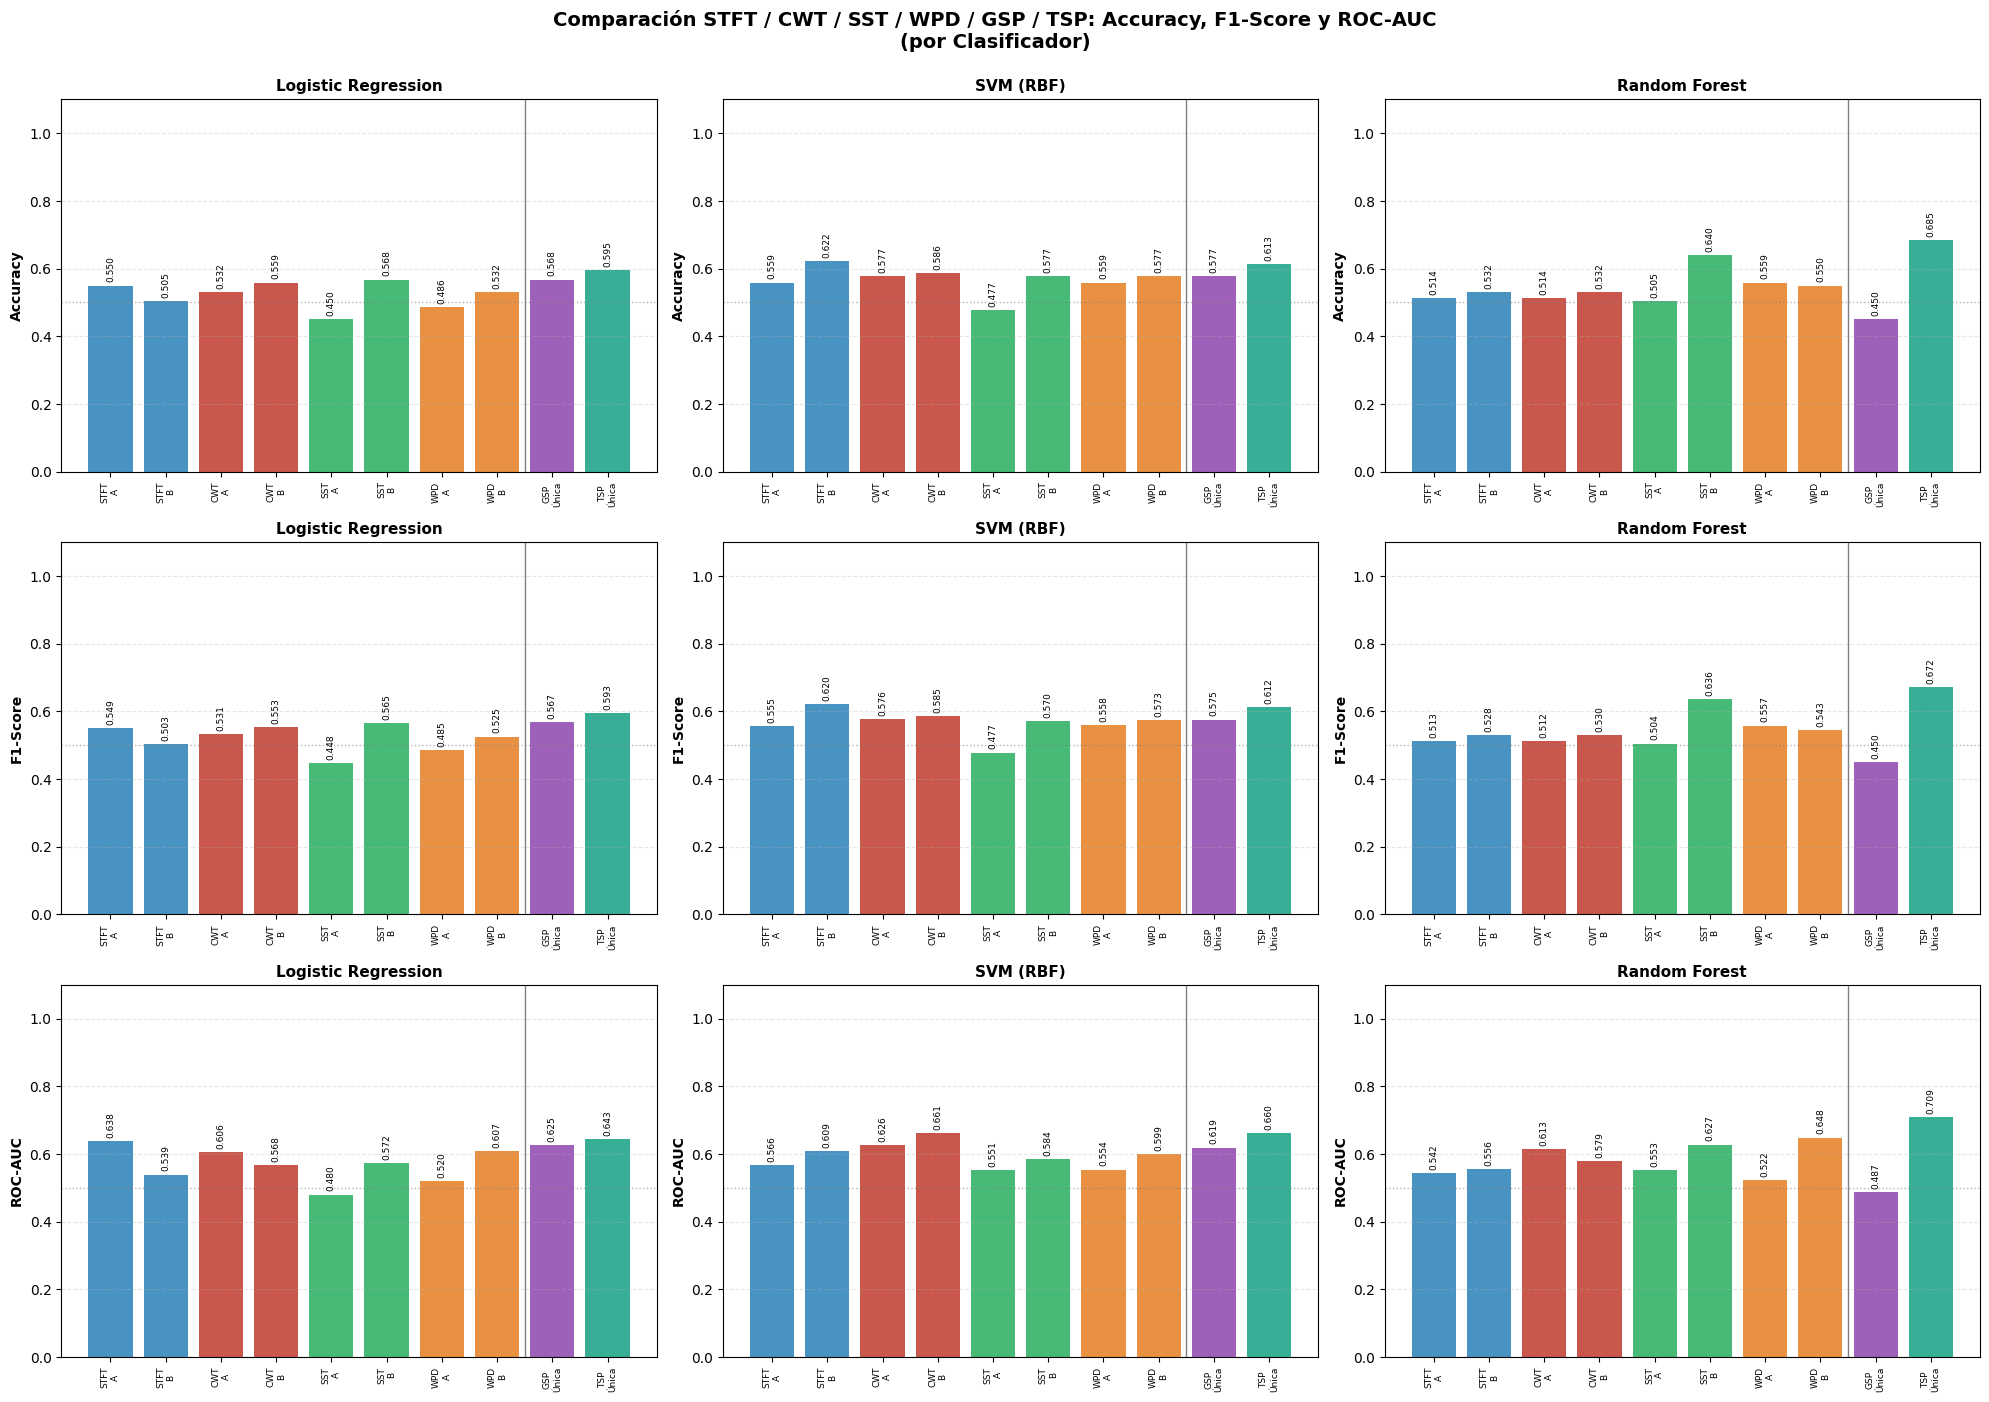

In [9]:
## Gráficos comparativos: 6 técnicas por métrica y clasificador
## (layout adaptado respecto al notebook 06: con GSP/TSP en Config Única,
##  la grilla "Config A vs B en eje X" ya no aplica de forma pareja a las 6
##  técnicas, así que se grafica una barra por cada combinación técnica+config)

metrics   = ['Accuracy', 'F1-Score', 'ROC-AUC']
clf_names = list(classifiers.keys())

# Orden de barras: todas las (técnica, config) combinaciones, TF primero, topo al final
bar_keys = []
for tecnica in TECNICAS_TF:
    for cfg in ['A (56 features)', 'B (16 features)']:
        bar_keys.append((tecnica, cfg))
for tecnica in TECNICAS_TOPO:
    bar_keys.append((tecnica, 'Única (4 features)'))

bar_labels = [f'{t}\n{c.split("(")[0].strip()}' for t, c in bar_keys]
bar_colors_list = [COLORS[t] for t, _ in bar_keys]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle('Comparación STFT / CWT / SST / WPD / GSP / TSP: Accuracy, F1-Score y ROC-AUC\n(por Clasificador)',
             fontsize=14, fontweight='bold', y=0.998)

x_pos = np.arange(len(bar_keys))

for mi, metric in enumerate(metrics):
    for ci, clf_name in enumerate(clf_names):
        ax = axes[mi, ci]
        subset = results_df[results_df['Clasificador'] == clf_name]

        vals = []
        for tecnica, cfg in bar_keys:
            row = subset[(subset['Técnica'] == tecnica) & (subset['Config'] == cfg)]
            vals.append(row[metric].values[0] if len(row) else np.nan)

        bars = ax.bar(x_pos, vals, color=bar_colors_list, alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2., v + 0.01,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

        # Separador visual entre TF (8 barras) y topológicas (2 barras)
        ax.axvline(x=7.5, color='black', linestyle='-', linewidth=1, alpha=0.5)

        ax.set_ylabel(metric, fontsize=10, fontweight='bold')
        ax.set_title(clf_name, fontsize=11, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(bar_labels, fontsize=6.5, rotation=90)
        ax.set_ylim([0.0, 1.1])
        ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6, linewidth=1)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


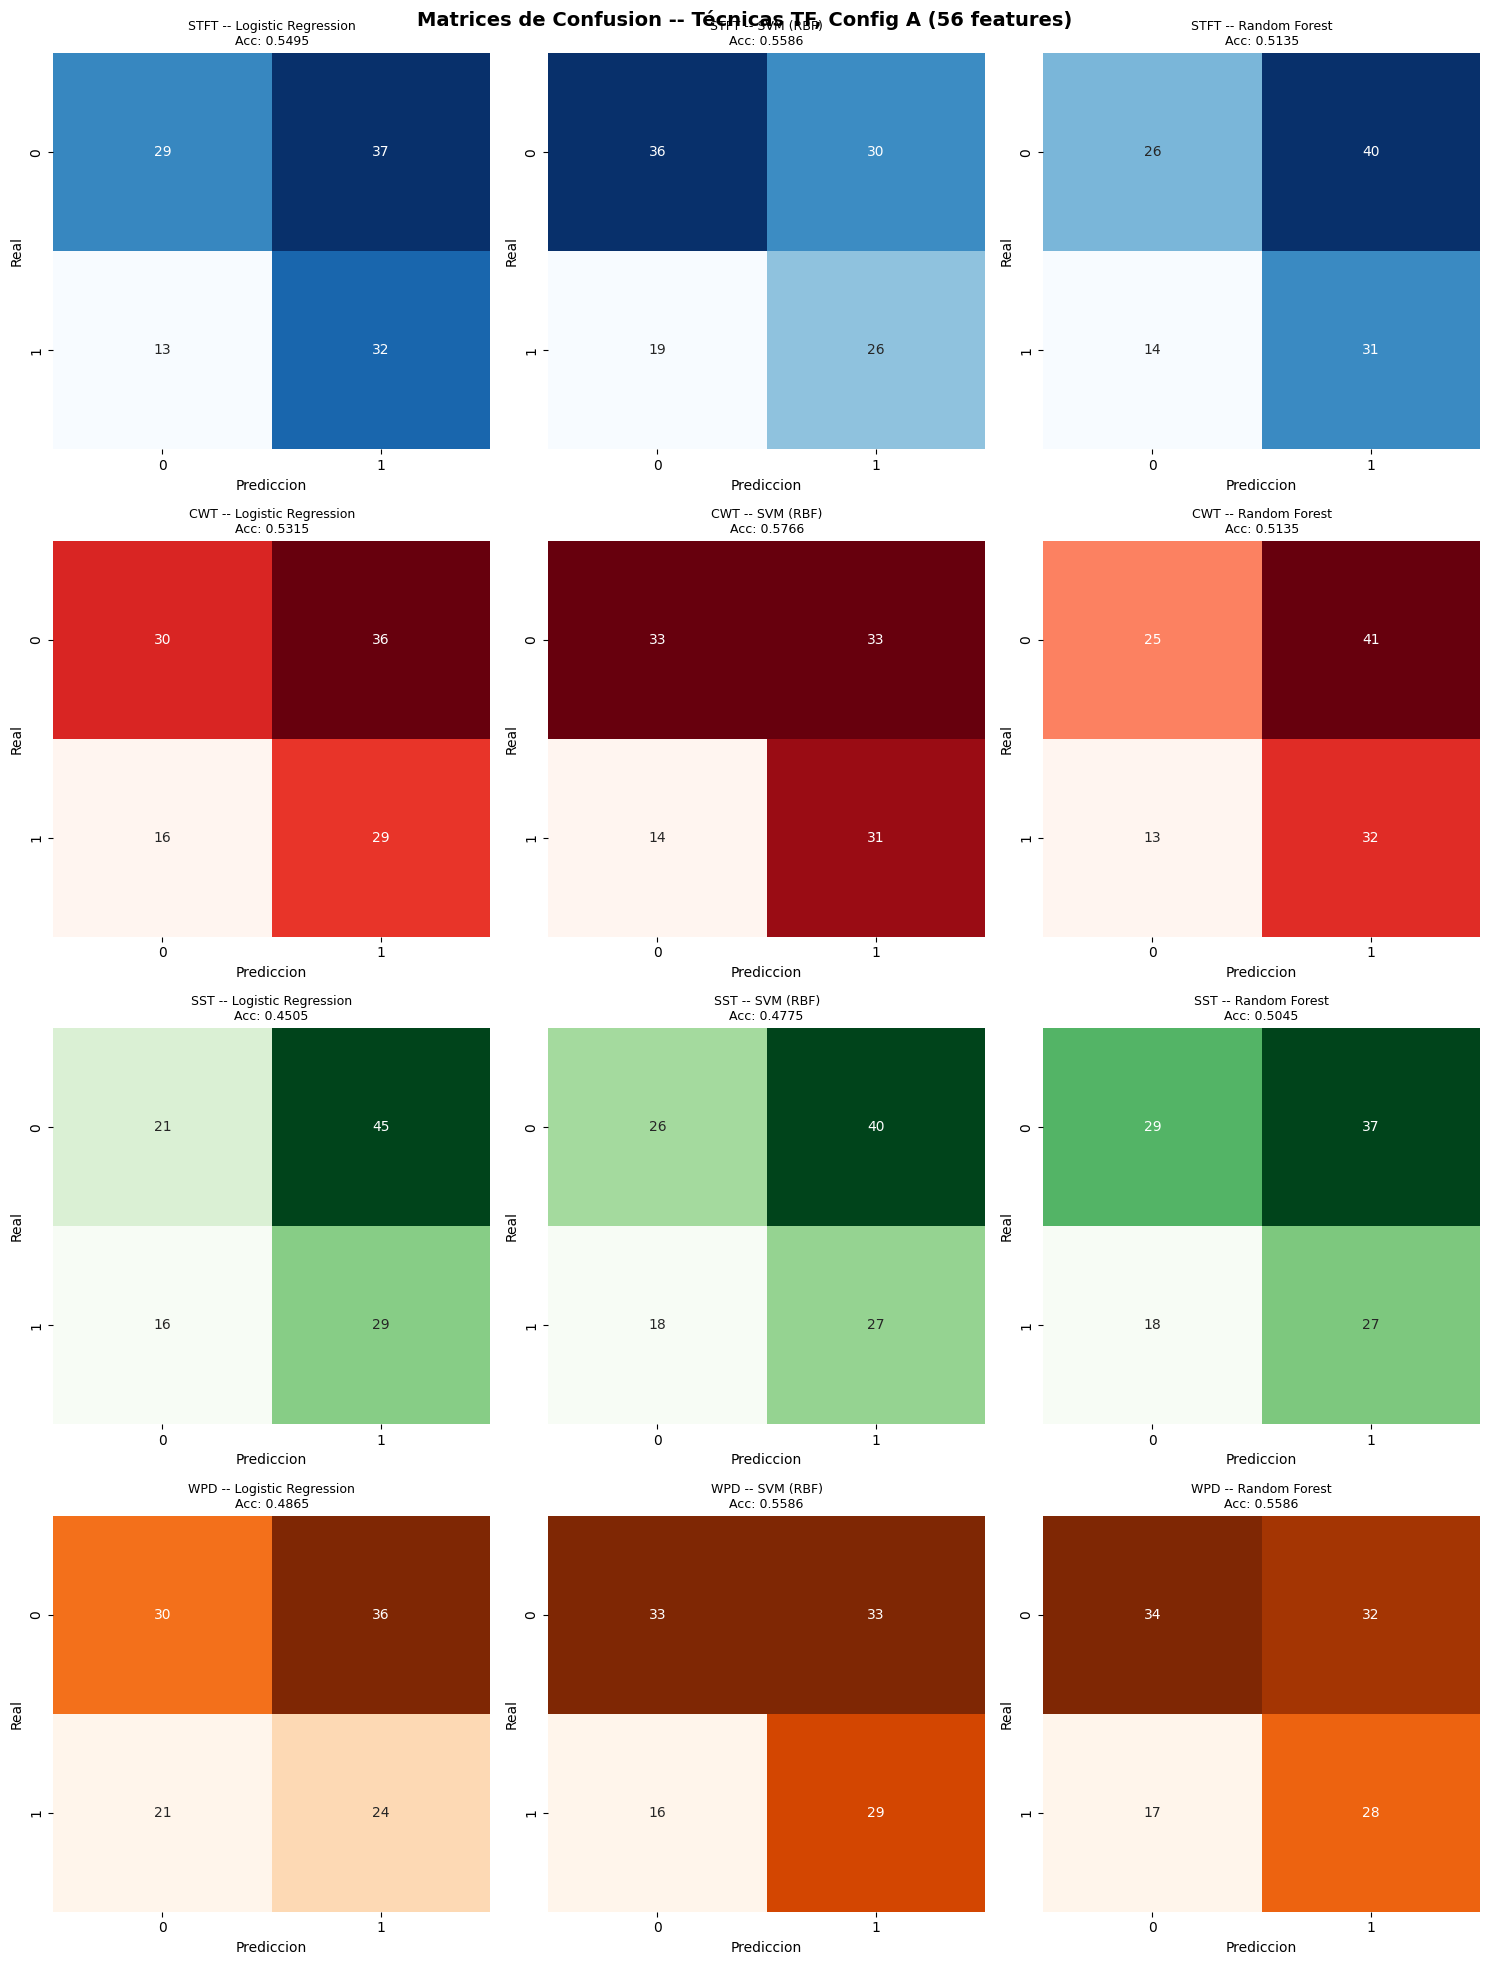

In [10]:
## Matrices de Confusión -- técnicas TF, Config A (56 features)

clf_names = list(classifiers.keys())
cmaps = {'STFT': 'Blues', 'CWT': 'Reds', 'SST': 'Greens', 'WPD': 'Oranges',
         'GSP': 'Purples', 'TSP': 'BuGn'}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle('Matrices de Confusion -- Técnicas TF, Config A (56 features)', fontsize=14, fontweight='bold')

for ti, tecnica in enumerate(TECNICAS_TF):
    for ci, clf_name in enumerate(clf_names):
        ax = axes[ti, ci]
        r = next(x for x in results if x['Técnica'] == tecnica
                 and x['Config'] == 'A (56 features)'
                 and x['Clasificador'] == clf_name)
        sns.heatmap(r['CM'], annot=True, fmt='d', cmap=cmaps[tecnica], ax=ax, cbar=False)
        ax.set_title(f'{tecnica} -- {clf_name}\nAcc: {r["Accuracy"]:.4f}', fontsize=9)
        ax.set_ylabel('Real')
        ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()


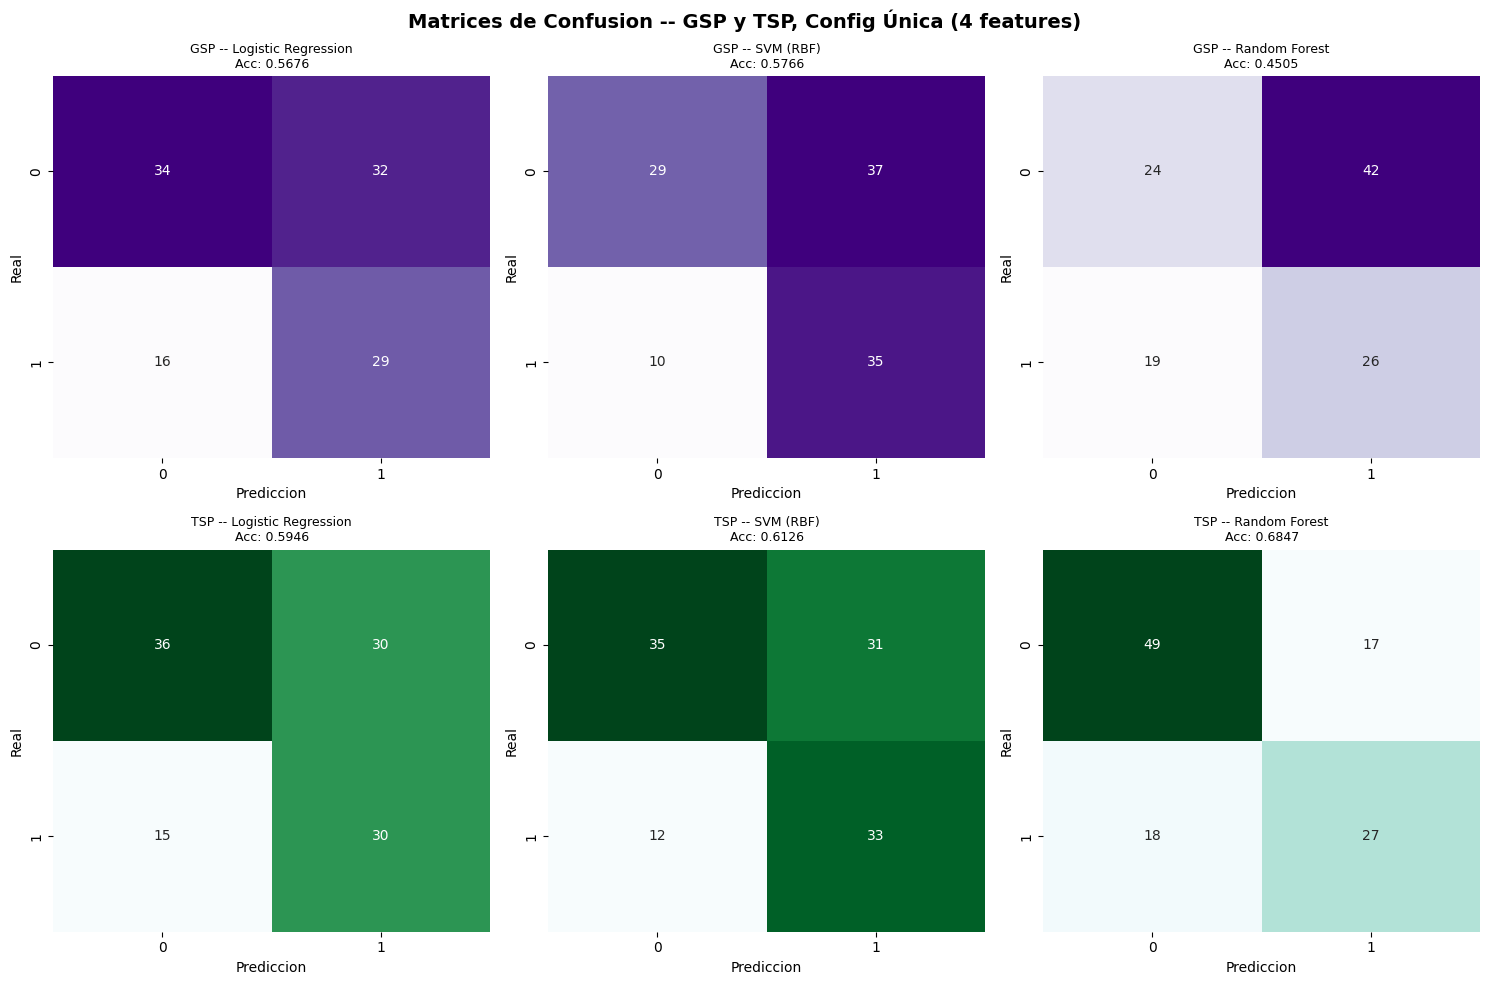

In [11]:
## Matrices de Confusión -- técnicas topológicas, Config Única (4 features)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Matrices de Confusion -- GSP y TSP, Config Única (4 features)', fontsize=14, fontweight='bold')

for ti, tecnica in enumerate(TECNICAS_TOPO):
    for ci, clf_name in enumerate(clf_names):
        ax = axes[ti, ci]
        r = next(x for x in results if x['Técnica'] == tecnica
                 and x['Config'] == 'Única (4 features)'
                 and x['Clasificador'] == clf_name)
        sns.heatmap(r['CM'], annot=True, fmt='d', cmap=cmaps[tecnica], ax=ax, cbar=False)
        ax.set_title(f'{tecnica} -- {clf_name}\nAcc: {r["Accuracy"]:.4f}', fontsize=9)
        ax.set_ylabel('Real')
        ax.set_xlabel('Prediccion')

plt.tight_layout()
plt.show()


# Sección 3: Importancia de Features

Análisis del Random Forest para identificar qué canales contribuyen más a
la clasificación en las técnicas TF, y qué features individuales dominan
en GSP y TSP (donde no hay canal que agrupar).

In [12]:
## Importancia de features -- Random Forest, técnicas TF, Config A

canales_alfa_list = ['O1', 'O2', 'P7', 'P8']
feature_names_a = [feature_names_tf[i] for i in idx_config_a]

importance_by_tecnica = {}

for tecnica in TECNICAS_TF:
    rf_result = next(r for r in results if r['Técnica'] == tecnica
                     and r['Config'] == 'A (56 features)'
                     and r['Clasificador'] == 'Random Forest')
    imp = rf_result['model'].feature_importances_
    imp_df = pd.DataFrame({'Feature': feature_names_a, 'Importance': imp})
    imp_df['Canal'] = imp_df['Feature'].str.split('_').str[0]
    canal_imp = imp_df.groupby('Canal')['Importance'].sum().sort_values(ascending=False)
    importance_by_tecnica[tecnica] = canal_imp

    pct_alfa = canal_imp[canal_imp.index.isin(canales_alfa_list)].sum() / canal_imp.sum() * 100
    print(f'{tecnica}: canal dominante = {canal_imp.index[0]} ({canal_imp.iloc[0]:.3f}) | canales alfa = {pct_alfa:.1f}%')


STFT: canal dominante = T7 (0.138) | canales alfa = 24.8%
CWT: canal dominante = T7 (0.125) | canales alfa = 25.1%
SST: canal dominante = O2 (0.116) | canales alfa = 32.8%
WPD: canal dominante = FC5 (0.132) | canales alfa = 27.4%


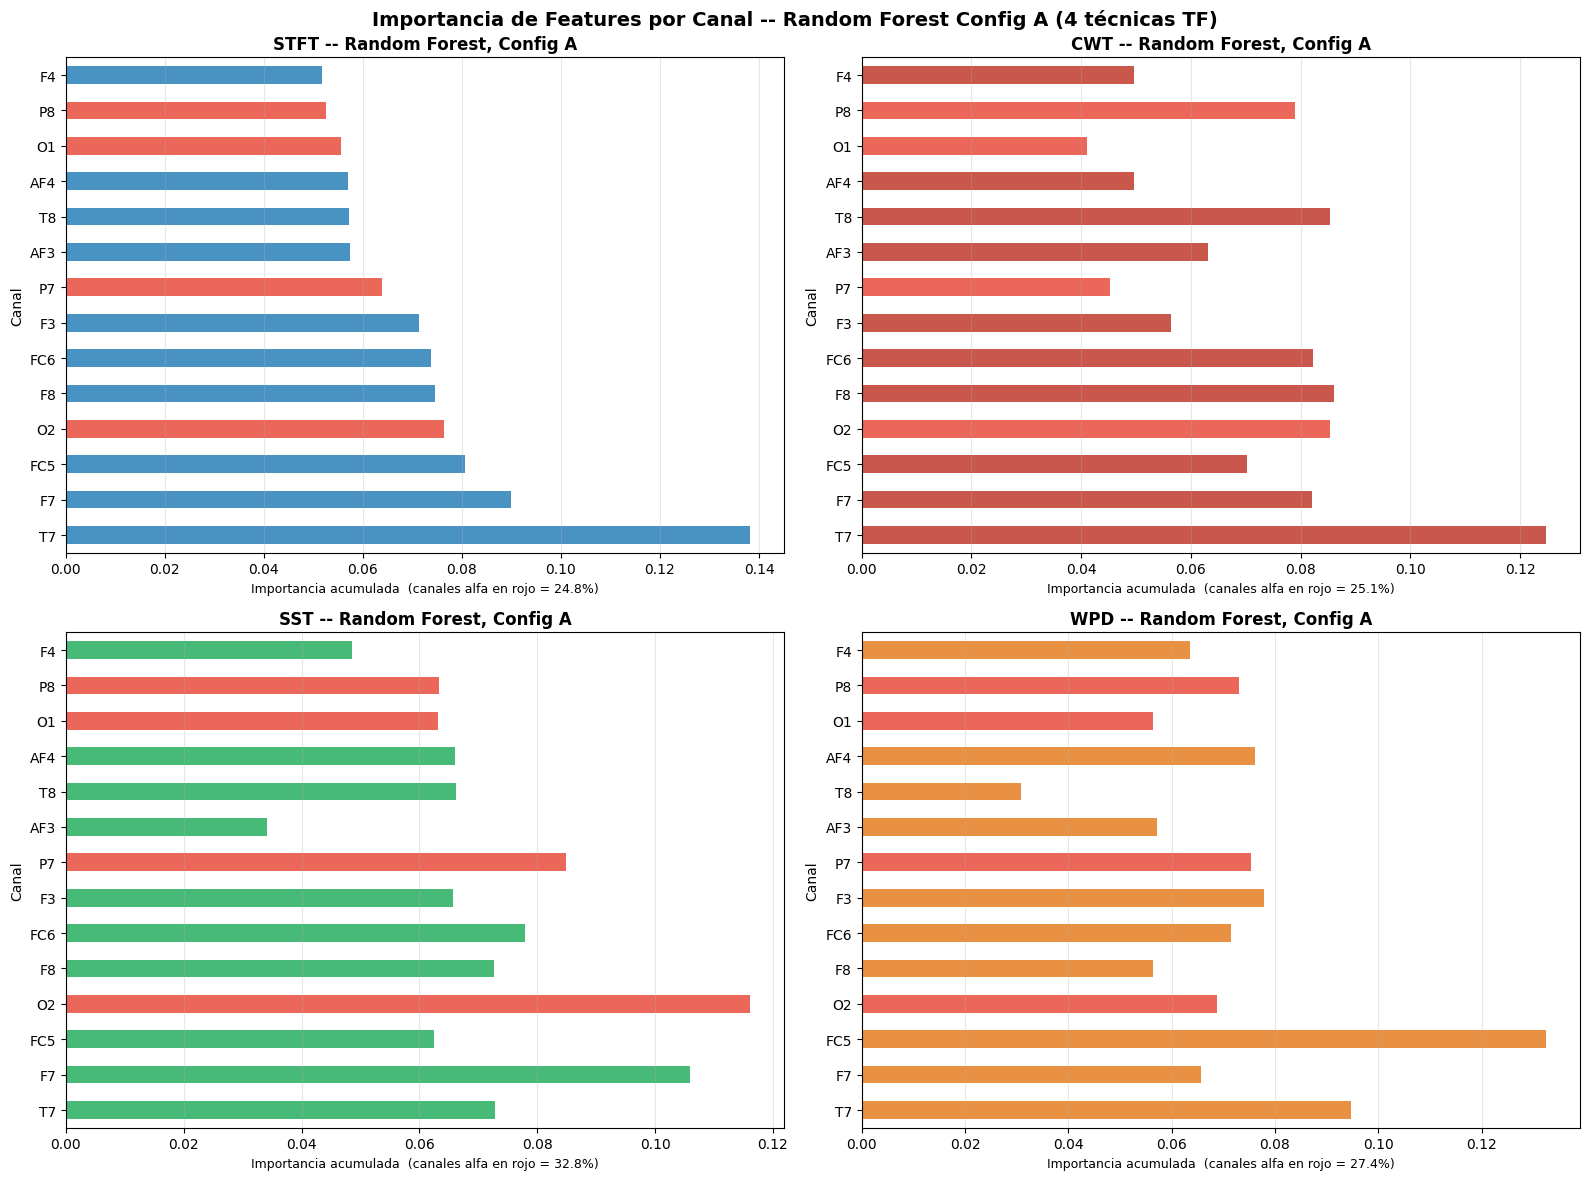

In [13]:
## Visualización: Importancia de features por canal -- técnicas TF

orden_canales = importance_by_tecnica['STFT'].sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Importancia de Features por Canal -- Random Forest Config A (4 técnicas TF)',
             fontsize=14, fontweight='bold')

for ax, tecnica in zip(axes.flat, TECNICAS_TF):
    canal_imp = importance_by_tecnica[tecnica].reindex(orden_canales, fill_value=0)
    colors_bar = ['#e74c3c' if c in canales_alfa_list else COLORS[tecnica] for c in canal_imp.index]
    canal_imp.plot(kind='barh', ax=ax, color=colors_bar, alpha=0.85)
    pct = importance_by_tecnica[tecnica][importance_by_tecnica[tecnica].index.isin(canales_alfa_list)].sum() \
          / importance_by_tecnica[tecnica].sum() * 100
    ax.set_title(f'{tecnica} -- Random Forest, Config A', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Importancia acumulada  (canales alfa en rojo = {pct:.1f}%)', fontsize=9)
    ax.set_ylabel('Canal', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


GSP: feature dominante = GSP_spatial_abs (0.257)
TSP: feature dominante = TSP_entropy (0.278)


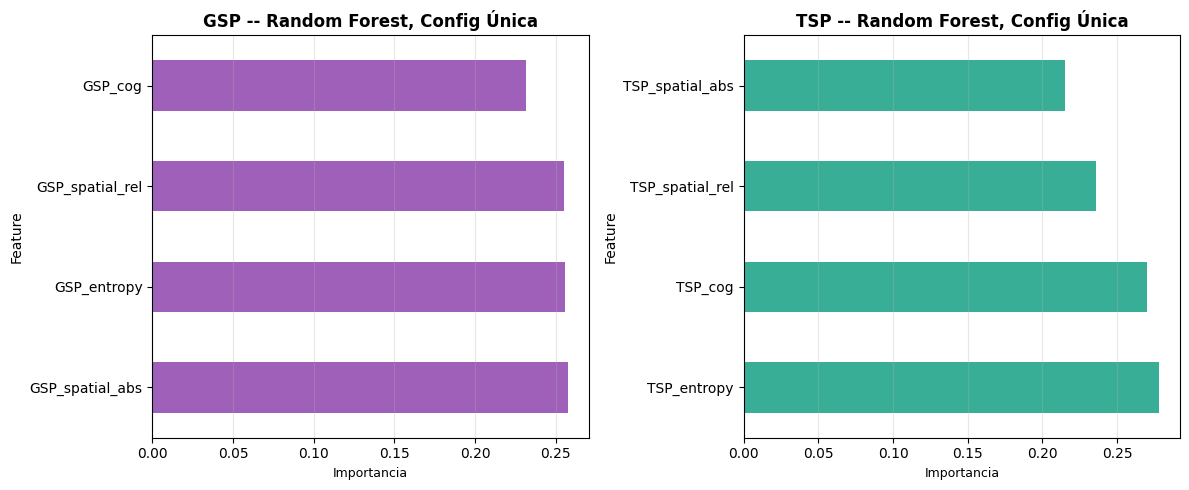

In [14]:
## Importancia de features -- Random Forest, GSP y TSP (Config Única)
## Sin agrupación por canal: GSP/TSP tienen solo 4 features individuales

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tecnica in zip(axes, TECNICAS_TOPO):
    rf_result = next(r for r in results if r['Técnica'] == tecnica
                     and r['Config'] == 'Única (4 features)'
                     and r['Clasificador'] == 'Random Forest')
    feat_cols = [c for c in datasets_raw[tecnica].columns if c not in ('label', 'Estado')]
    imp = rf_result['model'].feature_importances_
    imp_series = pd.Series(imp, index=feat_cols).sort_values(ascending=False)

    imp_series.plot(kind='barh', ax=ax, color=COLORS[tecnica], alpha=0.85)
    ax.set_title(f'{tecnica} -- Random Forest, Config Única', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia', fontsize=9)
    ax.set_ylabel('Feature', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

    print(f'{tecnica}: feature dominante = {imp_series.index[0]} ({imp_series.iloc[0]:.3f})')

plt.tight_layout()
plt.show()


# Sección 4: Resumen de lo realizado

Este notebook extendió el notebook 06, agregando GSP y TSP a la
comparación de clasificadores ya hecha para las 4 técnicas tiempo-frecuencia:

1. **Carga y verificación de alineación** de las 6 técnicas, condición
   necesaria para aplicar el mismo split por índice a todas.
2. **30 combinaciones entrenadas**: (4 técnicas TF × 2 configs + 2 técnicas
   topológicas × 1 config única) × 3 clasificadores.
3. **Tabla comparativa y rankings** por Accuracy, F1-Score y ROC-AUC, con
   desglose adicional por tipo de técnica (TF vs. Topológica).
4. **Matrices de confusión** separadas para TF (Config A) y para GSP/TSP.
5. **Importancia de features** — agrupada por canal para TF, individual
   (sin agrupar) para GSP/TSP, dado que estas no tienen estructura de canal.

Como con los notebooks 04b/05b, este notebook aún no se ha ejecutado contra
los datos reales — no se incluyen observaciones ni conclusiones sobre qué
técnica rindió mejor. Eso queda pendiente de la ejecución real.

### Una advertencia metodológica antes de interpretar resultados

El split único por bloques tiene el mismo problema de desbalance entre
train y test que ya se documentó en el notebook 07 para las técnicas TF
(62.9% clase 0 en test vs. 45.8% en train). Esa distorsión afecta a las
6 técnicas por igual, así que no invalida la comparación *relativa* entre
ellas, pero sí significa que **la Accuracy de este notebook no debe
tomarse como cifra final** — su contraparte corregida (Balanced Accuracy +
validación cruzada temporal) se calcula en el notebook **07b**, que es el
que de verdad permite responder con rigor si la ventaja de GSP/TSP
observada en discriminabilidad estadística (04b/05b) se sostiene también
en clasificación.